In [3]:
!pip install -q transformers datasets accelerate huggingface_hub seaborn scikit-learn
print("✅ OK")

✅ OK


In [4]:
from huggingface_hub import login
from google.colab import userdata

login(token=userdata.get('token_hf'))
print("✅ Connecté à HuggingFace !")

✅ Connecté à HuggingFace !


In [5]:
!git clone https://github.com/a126OPS/camembert-sentiment.git
print("✅ Repo cloné")

Cloning into 'camembert-sentiment'...
✅ Repo cloné


In [6]:
import os, json, torch, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
from datasets import load_dataset
from transformers import (
    CamembertTokenizer,
    CamembertForSequenceClassification,
    TrainingArguments, Trainer,
    EarlyStoppingCallback,
)
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix,
)

# ⚡ CONFIG
HF_USERNAME   = "a126OPS"
HF_REPO_ID    = f"{HF_USERNAME}/camembert-sentiment-allocine"
MODEL_NAME    = "camembert-base"
OUTPUT_DIR    = "/content/outputs"
MAX_LEN       = 256
BATCH_SIZE    = 16
EPOCHS        = 3
LEARNING_RATE = 2e-5
WARMUP_RATIO  = 0.1
WEIGHT_DECAY  = 0.01
SEED          = 42
LABEL2ID      = {"negative": 0, "positive": 1}
ID2LABEL      = {0: "negative", 1: "positive"}

torch.manual_seed(SEED)
np.random.seed(SEED)
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Device : {device}")
if device.type == "cuda":
    print(f"   GPU : {torch.cuda.get_device_name(0)}")
else:
    print("⚠️  Pas de GPU — va dans Runtime → Change runtime type → T4 GPU")

🖥️  Device : cuda
   GPU : Tesla T4


In [7]:
print("📦 Chargement AlloCiné...")
dataset = load_dataset("allocine")
print(f"Train      : {len(dataset['train']):,}")
print(f"Validation : {len(dataset['validation']):,}")
print(f"Test       : {len(dataset['test']):,}")

📦 Chargement AlloCiné...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

allocine/train-00000-of-00001.parquet:   0%|          | 0.00/60.0M [00:00<?, ?B/s]

allocine/validation-00000-of-00001.parqu(…):   0%|          | 0.00/7.58M [00:00<?, ?B/s]

allocine/test-00000-of-00001.parquet:   0%|          | 0.00/7.58M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/160000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/20000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/20000 [00:00<?, ? examples/s]

Train      : 160,000
Validation : 20,000
Test       : 20,000


In [8]:
print("🔤 Tokenisation...")
tokenizer = CamembertTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer(batch["review"], truncation=True,
                     padding="max_length", max_length=MAX_LEN)

tokenized = dataset.map(tokenize_fn, batched=True, batch_size=512)
tokenized = tokenized.rename_column("label", "labels")
tokenized.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
print("✅ Tokenisation terminée")

🔤 Tokenisation...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/811k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/160000 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

✅ Tokenisation terminée


In [9]:
print(f"🤗 Chargement {MODEL_NAME}...")
model = CamembertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2,
    id2label=ID2LABEL, label2id=LABEL2ID,
)
total = sum(p.numel() for p in model.parameters()) / 1e6
print(f"   {total:.1f}M paramètres")
print("✅ Modèle chargé")

🤗 Chargement camembert-base...


config.json:   0%|          | 0.00/508 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CamembertForSequenceClassification LOAD REPORT from: camembert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   110.6M paramètres
✅ Modèle chargé


In [10]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": round(accuracy_score(labels, preds), 4),
        "f1":       round(f1_score(labels, preds, average="weighted"), 4),
    }
print("✅ compute_metrics défini")

✅ compute_metrics défini


In [13]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    learning_rate=LEARNING_RATE,
    warmup_steps=500,
    weight_decay=WEIGHT_DECAY,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=200,
    report_to="none",
    seed=SEED,
    fp16=torch.cuda.is_available(),
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("🚀 Entraînement lancé...")
trainer.train()
print("✅ Entraînement terminé !")

🚀 Entraînement lancé...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.114853,0.103984,0.968700,0.968700
2,0.095669,0.110444,0.971600,0.971600
3,0.046787,0.139108,0.971000,0.971000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

✅ Entraînement terminé !


In [16]:
print(f"☁️  Push vers HuggingFace : {HF_REPO_ID}")
trainer.push_to_hub(HF_REPO_ID)
tokenizer.push_to_hub(HF_REPO_ID)
print(f"✅ https://huggingface.co/{HF_REPO_ID}")

☁️  Push vers HuggingFace : a126OPS/camembert-sentiment-allocine


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...outputs/model.safetensors:   0%|          |  553kB /  443MB            

  ...outputs/training_args.bin:   1%|1         |  71.0B / 5.20kB            

✅ https://huggingface.co/a126OPS/camembert-sentiment-allocine


📦 Chargement dataset + modèle...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

🧪 Inférence sur le test set (5 min)...
              precision    recall  f1-score   support

    negative     0.9787    0.9657    0.9721     10408
    positive     0.9633    0.9772    0.9702      9592

    accuracy                         0.9712     20000
   macro avg     0.9710    0.9714    0.9712     20000
weighted avg     0.9713    0.9712    0.9712     20000



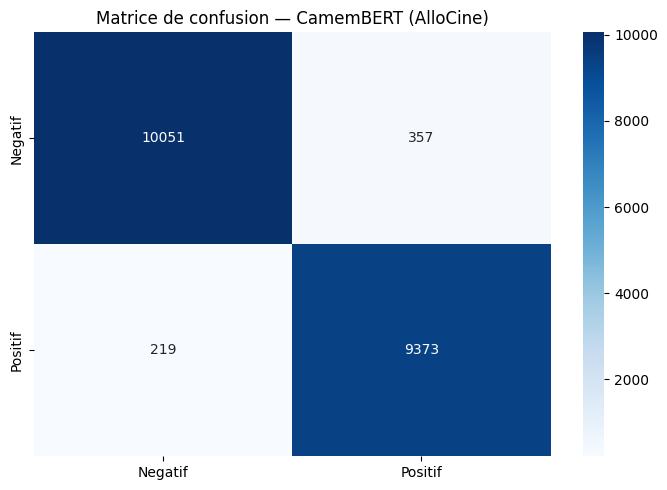

✅ confusion_matrix.png sauvegardé !


In [7]:
!pip install -q transformers datasets scikit-learn matplotlib seaborn

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datasets import load_dataset
from transformers import CamembertTokenizer, CamembertForSequenceClassification, pipeline
from sklearn.metrics import classification_report, confusion_matrix

Path("/content/outputs").mkdir(parents=True, exist_ok=True)

MODEL_ID = "a126OPS/outputs"
MAX_LEN  = 256

print("📦 Chargement dataset + modèle...")
dataset   = load_dataset("allocine")
tokenizer = CamembertTokenizer.from_pretrained(MODEL_ID)
model     = CamembertForSequenceClassification.from_pretrained(MODEL_ID)
model.eval()

print("🧪 Inférence sur le test set (5 min)...")
clf = pipeline("text-classification", model=model, tokenizer=tokenizer,
               device=0 if torch.cuda.is_available() else -1, batch_size=64)

# ← correction ici : list() pour convertir en liste Python
test_reviews = list(dataset["test"]["review"])
test_labels  = list(dataset["test"]["label"])

results = clf(test_reviews, truncation=True, max_length=MAX_LEN)
preds   = [1 if r["label"] == "positive" else 0 for r in results]

print(classification_report(test_labels, preds,
      target_names=["negative", "positive"], digits=4))

# Matrice de confusion
cm = confusion_matrix(test_labels, preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negatif', 'Positif'],
            yticklabels=['Negatif', 'Positif'])
plt.title('Matrice de confusion — CamemBERT (AlloCine)')
plt.tight_layout()
plt.savefig("/content/outputs/confusion_matrix.png", dpi=150)
plt.show()
print("✅ confusion_matrix.png sauvegardé !")

In [8]:
from google.colab import userdata
import shutil, os

GITHUB_TOKEN = userdata.get('token_git')

os.chdir("/content/camembert-sentiment")

# Copie les graphiques
for f in ["confusion_matrix.png", "training_curves.png"]:
    src = f"/content/outputs/{f}"
    if os.path.exists(src):
        shutil.copy(src, f"assets/{f}")
        print(f"✅ {f} copié")
    else:
        print(f"⚠️  {f} non trouvé")

!git add .
!git commit -m "feat: add evaluation assets — 97.16% accuracy"
!git push
print("✅ GitHub mis à jour !")

✅ confusion_matrix.png copié
⚠️  training_curves.png non trouvé
[main beffec9] feat: add evaluation assets — 97.16% accuracy
 1 file changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 assets/confusion_matrix.png
Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (4/4), 30.06 KiB | 1.88 MiB/s, done.
Total 4 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.com/a126OPS/camembert-sentiment.git
   d341826..beffec9  main -> main
✅ GitHub mis à jour !


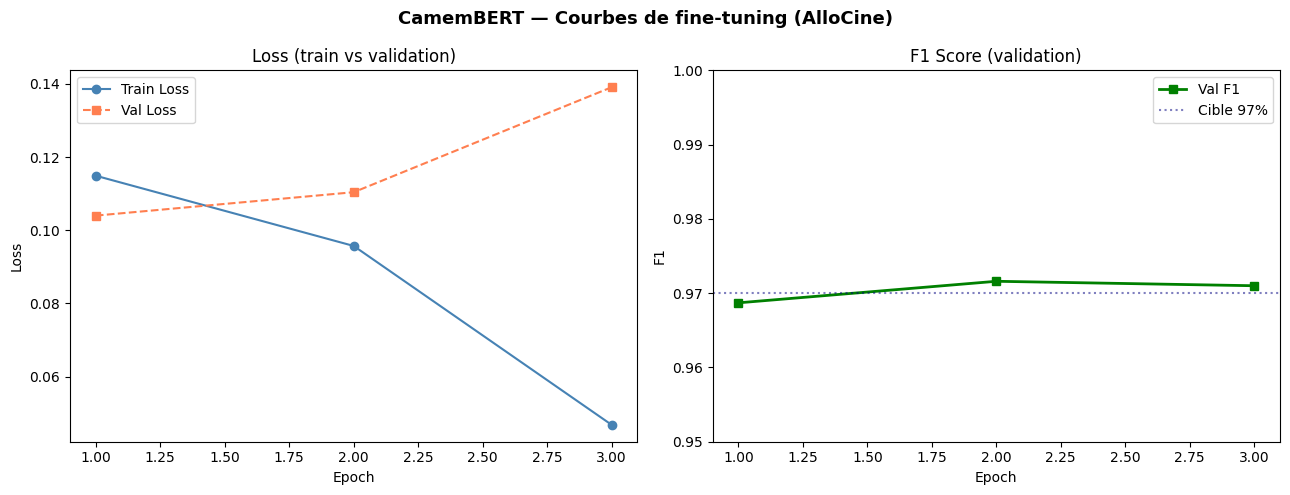

✅ training_curves.png sauvegardé !


In [9]:
import matplotlib.pyplot as plt

# Données réelles de ton entraînement
epochs     = [1, 2, 3]
train_loss = [0.1149, 0.0957, 0.0468]
val_loss   = [0.1040, 0.1104, 0.1391]
val_f1     = [0.9687, 0.9716, 0.9710]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(epochs, train_loss, marker='o', color='steelblue', label='Train Loss')
axes[0].plot(epochs, val_loss,   marker='s', color='coral', linestyle='--', label='Val Loss')
axes[0].set_title('Loss (train vs validation)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(epochs, val_f1, marker='s', color='green', linewidth=2, label='Val F1')
axes[1].axhline(0.97, color='navy', linestyle=':', alpha=0.5, label='Cible 97%')
axes[1].set_title('F1 Score (validation)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1')
axes[1].set_ylim(0.95, 1.0)
axes[1].legend()

plt.suptitle('CamemBERT — Courbes de fine-tuning (AlloCine)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/content/outputs/training_curves.png", dpi=150)
plt.show()
print("✅ training_curves.png sauvegardé !")

In [10]:
import shutil, os
from google.colab import userdata

GITHUB_TOKEN = userdata.get('token_git')
os.chdir("/content/camembert-sentiment")
shutil.copy("/content/outputs/training_curves.png", "assets/training_curves.png")
!git add .
!git commit -m "feat: add training curves"
!git push
print("✅ GitHub complet !")

[main a290814] feat: add training curves
 1 file changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 assets/training_curves.png
Enumerating objects: 6, done.
Counting objects: 100% (6/6), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 72.40 KiB | 12.07 MiB/s, done.
Total 4 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.com/a126OPS/camembert-sentiment.git
   beffec9..a290814  main -> main
✅ GitHub complet !


In [11]:
from google.colab import userdata
import shutil, os, json

GITHUB_TOKEN = userdata.get('token_git')
os.chdir("/content/camembert-sentiment")

# Sauvegarde le notebook Colab actuel
os.makedirs("notebooks", exist_ok=True)

# Crée un notebook simplifié avec les vrais résultats
notebook = {
 "nbformat": 4,
 "nbformat_minor": 4,
 "metadata": {
   "kernelspec": {"display_name": "Python 3", "language": "python", "name": "python3"},
   "language_info": {"name": "python", "version": "3.10.0"},
   "colab": {"gpuType": "T4"},
   "accelerator": "GPU"
 },
 "cells": [
   {"cell_type": "markdown", "metadata": {}, "source": ["# CamemBERT — Analyse de Sentiment en Français\n", "\n", "**Résultats :**\n", "- Accuracy : **97.16%**\n", "- F1 (weighted) : **97.16%**\n", "- Dataset : AlloCiné (160k avis)\n", "- Base model : camembert-base\n", "- Epochs : 3 | Batch size : 16 | LR : 2e-5\n"]},
   {"cell_type": "markdown", "metadata": {}, "source": ["## Courbes d'entraînement\n", "| Epoch | Train Loss | Val Loss | Val F1 |\n", "|---|---|---|---|\n", "| 1 | 0.1149 | 0.1040 | 96.87% |\n", "| 2 | 0.0957 | 0.1104 | 97.16% |\n", "| 3 | 0.0468 | 0.1391 | 97.10% |\n"]},
   {"cell_type": "markdown", "metadata": {}, "source": ["## Matrice de confusion\n", "![Confusion Matrix](../assets/confusion_matrix.png)\n"]},
   {"cell_type": "markdown", "metadata": {}, "source": ["## Courbes de training\n", "![Training Curves](../assets/training_curves.png)\n"]},
   {"cell_type": "markdown", "metadata": {}, "source": ["## Inférence live\n"]},
   {"cell_type": "code", "execution_count": None, "metadata": {}, "outputs": [], "source": ["from transformers import pipeline\n", "\n", "clf = pipeline('text-classification', model='a126OPS/outputs')\n", "\n", "phrases = [\n", "    'Ce film est absolument magnifique, une oeuvre d art pure.',\n", "    'Scenario plat, jeu d acteurs catastrophique, une vraie deception.',\n", "    'Une performance epoustouflante ! Je recommande chaudement.',\n", "]\n", "\n", "for p in phrases:\n", "    r = clf(p, truncation=True, max_length=256)[0]\n", "    print(f\"{r['label']:10} ({r['score']:.2%}) — {p[:60]}\")\n"]}
 ]
}

with open("notebooks/exploration.ipynb", "w") as f:
    json.dump(notebook, f, indent=2)
print("✅ Notebook créé")

!git add .
!git commit -m "feat: add exploration notebook with results"
!git push
print("✅ GitHub complet avec notebook !")

✅ Notebook créé
[main d303b15] feat: add exploration notebook with results
 1 file changed, 91 insertions(+)
 create mode 100644 notebooks/exploration.ipynb
Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (4/4), 1.30 KiB | 1.30 MiB/s, done.
Total 4 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.com/a126OPS/camembert-sentiment.git
   a290814..d303b15  main -> main
✅ GitHub complet avec notebook !
